In [26]:
import os
from pathlib import Path

from dotenv import load_dotenv
import pandas as pd
import yaml

from src.tools.presets import get_list_of_presets
from src.tools.read.rerank.load_rerank import load_analyze_retrieval_dataframes


load_dotenv()

ANALYZE_RETRIEVAL_DIR = Path(os.getenv("ANALYZE_RETRIEVAL_DIR"))

with open("params_lit.yaml", "r", encoding="utf-8") as f:
    params = yaml.safe_load(f)

datasets_cfg = params.get("preprocess_datasets").get("datasets")
if not datasets_cfg:
    raise ValueError("Nie znaleziono datasets_download w params.yaml")

chunking_cfg = params.get("chunking").get("methods")
if not chunking_cfg:
    raise ValueError("Nie znaleziono chunking_methods w params.yaml")

embed_cfg = params.get("vector_embed").get("methods")
if not embed_cfg:
    raise ValueError("Nie znaleziono vector_embed_methods w params.yaml")

search_cfg = params.get("search").get("methods")
if not embed_cfg:
    raise ValueError("Nie znaleziono search methods w params.yaml")

rerank_cfg = params.get("rerank").get("methods")
if not embed_cfg:
    raise ValueError("Nie znaleziono rerank methods w params.yaml")

analyze_cfg = params.get("analyze_retrieval").get("methods")
if not analyze_cfg:
    raise ValueError("Nie znaleziono analyze_retrieval_methods w params.yaml")

splits = params.get("chunking").get("splits")
if not splits:
    raise ValueError("Nie znaleziono splits w params.yaml")

dataset_names, dataset_params_names = get_list_of_presets(datasets_cfg)
chunking_names, chunking_params_names = get_list_of_presets(chunking_cfg)
embed_names, embed_params_names = get_list_of_presets(embed_cfg)
search_names, search_params_names = get_list_of_presets(search_cfg)
rerank_names, rerank_params_names = get_list_of_presets(rerank_cfg)
analyze_retrieval_names, analyze_retrieval_params_names = get_list_of_presets(analyze_cfg)

configs = []
for dataset, dataset_params in zip(dataset_names, dataset_params_names):
    for chunking, chunking_params in zip(chunking_names, chunking_params_names):
        for embed, embed_params in zip(embed_names, embed_params_names):
            if 'local' in embed_params:
                continue
            for search, search_params in zip(search_names, search_params_names):
                for rerank, rerank_params in zip(rerank_names, rerank_params_names):
                    for analyze, analyze_params in zip(analyze_retrieval_names, analyze_retrieval_params_names):
                            for split in splits:
                                configs.append({
                                    "dataset_name": dataset,
                                    "dataset_params_name": dataset_params,
                                    "chunking_name": chunking,
                                    "chunking_params_name": chunking_params,
                                    "embed_name": embed,
                                    "embed_params_name": embed_params,
                                    "search_name": search,
                                    "search_params_name": search_params,
                                    "rerank_name": rerank,
                                    "rerank_params_name": rerank_params,
                                    "analyze_retrieval_name": analyze,
                                    "analyze_retrieval_params_name": analyze_params,
                                    "split_name": split
                                })
retrieval_df = load_analyze_retrieval_dataframes(ANALYZE_RETRIEVAL_DIR, configs)
# acc_cols = pd.DataFrame(
#     retrieval_df["Accuracy@1-5"].tolist(),
#     index=retrieval_df.index
# )

# acc_cols.columns = [f"Accuracy@{i+1}" for i in range(acc_cols.shape[1])]

# # usuń starą listę + stare accuracy kolumny
# cols_to_drop = ["Accuracy@1-5"] + [c for c in retrieval_df.columns if c.startswith("Accuracy@")]

# retrieval_df = retrieval_df.drop(columns=cols_to_drop).join(acc_cols)

metric_cols = [
    "Accuracy@1",
    "Accuracy@2",
    "Accuracy@3",
    "Accuracy@4",
    "Accuracy@5",
    "Recall@10",
    "MRR@10",
    "NDCG@10",
    "rerank_result_time",
]

# reszta kolumn
other_cols = [c for c in retrieval_df.columns if c not in metric_cols]

metric_cols = [
    "Accuracy@1",
    "Accuracy@2",
    "Accuracy@3",
    "Accuracy@4",
    "Accuracy@5",
    "Recall@10",
    "MRR@10",
    "NDCG@10",
    "rerank_result_time",
]

# reszta kolumn
other_cols = [c for c in retrieval_df.columns if c not in metric_cols]
retrieval_df

rerank_result_time  \
dataset_name dataset_params_name chunking_name      chunking_params_name embed_name embed_params_name search_name search_params_name rerank_name rerank_params_name analyze_retrieval_name analyze_retrieval_params_name split_name                       
literaryQA   default             chonkie_semantic   norm                 FAISS      default_global    faiss       default_top20      reranker    default_top20      analyze_retrieval      default                       test                248.572446   
                                                                                                                                                 default_top20_op   analyze_retrieval      default                       test                248.572446   
                                 fixed_size         norm_token           FAISS      default_global    faiss       default_top20      reranker    default_top20      analyze_retrieval      default                       test                185.904757   
                                                                                                                                                 default_top20_op   analyze_retrieval      default                       test                185.904757   
                                 lumber             default_vllm         FAISS      default_global    faiss       default_top20      reranker    default_top20      analyze_retrieval      default                       test                225.848028   
                                                                                                                                                 default_top20_op   analyze_retrieval      default                       test                225.848028   
                                 max_min            norm                 FAISS      default_global    faiss       default_top20      reranker    default_top20      analyze_retrieval      default                       test                247.644651   
                                                                                                                                                 default_top20_op   analyze_retrieval      default                       test                247.644651   
                                 neural             default              FAISS      default_global    faiss       default_top20      reranker    default_top20      analyze_retrieval      default                       test                380.957451   
                                                                                                                                                 default_top20_op   analyze_retrieval      default                       test                380.957451   
                                 recursive          norm                 FAISS      default_global    faiss       default_top20      reranker    default_top20      analyze_retrieval      default                       test                193.504015   
                                                                                                                                                 default_top20_op   analyze_retrieval      default                       test                193.504015   
                                 recursive_semantic norm                 FAISS      default_global    faiss       default_top20      reranker    default_top20      analyze_retrieval      default                       test                205.079320   
                                                                                                                                                 default_top20_op   analyze_retrieval      default                       test                205.079320   
                                 sequential_hac     norm                 FAISS      default_global    faiss       default_top20      reranker    default_top20      analyze_retrieval      default                   

In [25]:
s1 = retrieval_df

In [27]:
import matplotlib.pyplot as plt
import numpy as np
import math


def plot_metrics_subplots(df, metric_cols, ncols=2):

    labels = [
        " | ".join(map(str, idx))
        for idx in df.index
    ]

    n_metrics = len(metric_cols)
    nrows = math.ceil(n_metrics / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(6 * ncols, 4 * nrows),
        constrained_layout=True
    )

    axes = np.array(axes).reshape(-1)

    colors = plt.cm.tab20(np.linspace(0, 1, len(df)))

    for ax, metric in zip(axes, metric_cols):

        for i, (label, color) in enumerate(zip(labels, colors)):

            value = df.iloc[i][metric]

            bar = ax.bar(
                i,
                value,
                color=color,
                label=label if metric == metric_cols[0] else None
            )

            # dodanie wartości nad słupkiem
            ax.text(
                i,
                value + 0.02,          # lekko nad słupkiem
                f"{value:.2f}",        # format liczby
                ha='center',
                va='bottom',
                fontsize=9
            )

        ax.set_title(metric)
        ax.set_ylim(0, 1.1)

        # ukryj x ticki
        ax.set_xticks([])

    # usuń puste subploty
    for ax in axes[n_metrics:]:
        fig.delaxes(ax)

    # wspólna legenda
    fig.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5)
    )

    return fig, axes

In [28]:
merged_df = pd.concat([retrieval_df, s1])

In [29]:
merged_df

rerank_result_time  \
dataset_name dataset_params_name chunking_name      chunking_params_name embed_name embed_params_name search_name search_params_name rerank_name rerank_params_name analyze_retrieval_name analyze_retrieval_params_name split_name                       
literaryQA   default             chonkie_semantic   norm                 FAISS      default_global    faiss       default_top20      reranker    default_top20      analyze_retrieval      default                       test                248.572446   
                                                                                                                                                 default_top20_op   analyze_retrieval      default                       test                248.572446   
                                 fixed_size         norm_token           FAISS      default_global    faiss       default_top20      reranker    default_top20      analyze_retrieval      default                       test                185.904757   
                                                                                                                                                 default_top20_op   analyze_retrieval      default                       test                185.904757   
                                 lumber             default_vllm         FAISS      default_global    faiss       default_top20      reranker    default_top20      analyze_retrieval      default                       test                225.848028   
...                                                                                                                                                                                                                                                 ...   
novelQA      default             recursive          norm                 FAISS      default_global    faiss       default_top20      reranker    default_top20_op   analyze_retrieval      default                       all                 437.795112   
                                 recursive_semantic norm                 FAISS      default_global    faiss       default_top20      reranker    default_top20      analyze_retrieval      default                       all                 481.584526   
                                                                                                                                                 default_top20_op   analyze_retrieval      default                       all                 481.584526   
                                 sequential_hac     norm                 FAISS      default_global    faiss       default_top20      reranker    default_top20      analyze_retrieval      default                       all                 628.256461   
                                                                                                                                                 default_top20_op   analyze_retrieval      default                       all                 628.256461   

                                                                                                                                                                                                                                     Accuracy@1  \
dataset_name dataset_params_name chunking_name      chunking_params_name embed_name embed_params_name search_name search_params_name rerank_name rerank_params_name analyze_retrieval_name analyze_retrieval_params_name split_name               
literaryQA   default             chonkie_semantic   norm                 FAISS      default_global    faiss       default_top20      reranker    default_top20      analyze_retrieval      default                       test            0.7548   
                                                                                                                                                 default_top20_op   analyze_retrieval      default                       test            0.3

In [20]:
column = "Recall@10"

for dataset_name, chunking_name, value in zip(
    merged_df.index.get_level_values("dataset_name"),
    merged_df.index.get_level_values("chunking_name"),
    merged_df[column]
):
    print(f'Dataset: {dataset_name}, Chunking: {chunking_name}, Value: {value}')

Dataset: infiniteBenchChoice, Chunking: chonkie_semantic, Value: 0.1176
Dataset: infiniteBenchChoice, Chunking: fixed_size, Value: 0.1169
Dataset: infiniteBenchChoice, Chunking: lumber, Value: 0.1175
Dataset: infiniteBenchChoice, Chunking: max_min, Value: 0.1204
Dataset: infiniteBenchChoice, Chunking: neural, Value: 0.1932
Dataset: infiniteBenchChoice, Chunking: recursive, Value: 0.1182
Dataset: infiniteBenchChoice, Chunking: recursive_semantic, Value: 0.1194
Dataset: infiniteBenchChoice, Chunking: sequential_hac, Value: 0.1513
Dataset: infiniteBenchQA, Chunking: chonkie_semantic, Value: 0.0963
Dataset: infiniteBenchQA, Chunking: fixed_size, Value: 0.0965
Dataset: infiniteBenchQA, Chunking: lumber, Value: 0.0946
Dataset: infiniteBenchQA, Chunking: max_min, Value: 0.1007
Dataset: infiniteBenchQA, Chunking: neural, Value: 0.1548
Dataset: infiniteBenchQA, Chunking: recursive, Value: 0.0962
Dataset: infiniteBenchQA, Chunking: recursive_semantic, Value: 0.0956
Dataset: infiniteBenchQA, Chun

In [61]:
import matplotlib.pyplot as plt
import numpy as np


def plot_metrics(df, metric_cols):

    labels = []

    for idx in df.index:
        first_idx = idx[2]
        second_idx = idx[9]

        label_type = (
            "Order Preserve"
            if "_op" in str(second_idx)
            else "Reranker"
        )

        labels.append(f"{first_idx} | {label_type}")

    n_groups = len(df)
    n_metrics = len(metric_cols)

    x = np.arange(n_groups)
    width = 0.8 / n_metrics

    fig, ax = plt.subplots(
        figsize=(12, 6),
        constrained_layout=True
    )

    # pary kolorów: mocny -> faded
    base_colors = [
        "#1f77b4",  # blue
        "#ff7f0e",  # orange
        "#2ca02c",  # green
        "#d62728",  # red
        "#9467bd",  # purple
        "#8c564b",  # brown
        "#e377c2",  # pink
        "#7f7f7f",  # gray
    ]

    for i, metric in enumerate(metric_cols):

        values = df[metric].values

        for j, value in enumerate(values):

            # każdy słupek dostaje kolejną parę kolorów
            color_idx = (i * n_groups + j) // 2
            color = base_colors[color_idx % len(base_colors)]

            alpha = 1.0 if (i * n_groups + j) % 2 == 0 else 0.35

            ax.bar(
                x[j] + i * width,
                value,
                width,
                color=color,
                alpha=alpha
            )

            ax.text(
                x[j] + i * width,
                value + 0.02,
                f"{value*100:.2f}",
                ha="center",
                va="bottom",
                fontsize=9
            )

    ax.set_title(
        "nDCG@10 Retrieval Performance on LiteraryQA Dataset",
        fontsize=16
    )

    ax.set_ylabel("nDCG@10")
    ax.set_ylim(0, 1.1)

    ax.set_xticks(
        x + width * (n_metrics - 1) / 2
    )

    ax.set_xticklabels(
        labels,
        rotation=45,
        ha="right"
    )

    return fig, ax

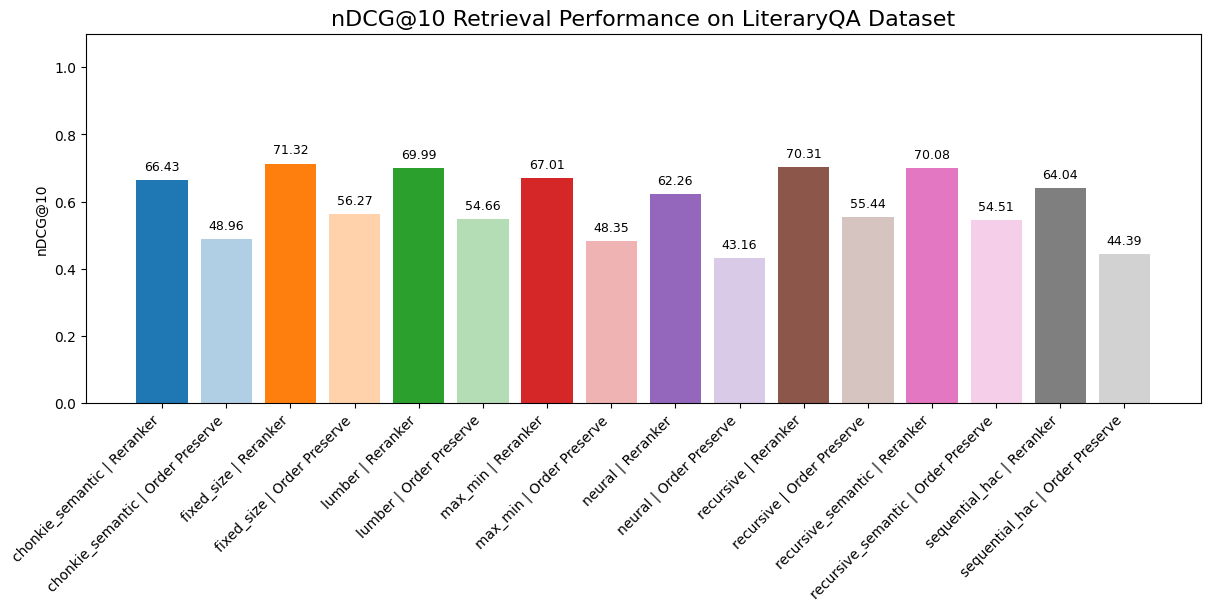

In [62]:
metric_cols = [
    # "Accuracy@1",
    # "Accuracy@2",
    # "Accuracy@3",
    # "Accuracy@4",
    # "Accuracy@5",
    # "Recall@10",
    # "MRR@10",
    "NDCG@10",
]
# plot_df = merged_df[
#     ~merged_df.index.get_level_values("rerank_params_name").str.contains("_op", na=False)
# ]
plot_df = merged_df[
    merged_df.index.get_level_values("rerank_name").str.contains("reranker", na=False)
]
plot_df = plot_df[
    plot_df.index.get_level_values("dataset_name").str.contains("literaryQA", na=False)
]
fig, axes = plot_metrics(plot_df, metric_cols)
plt.show()

In [9]:
from matplotlib import pyplot as plt


def plot_time(df, time_column_name):
    labels = [
        " | ".join(map(str, idx))
        for idx in df.index
    ]

    fig, ax = plt.subplots(figsize=(14, 5))

    x = range(len(df))

    ax.bar(x, df[time_column_name])

    ax.set_title(time_column_name)
    ax.set_ylabel("time [s]")

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=90)

    return fig, ax

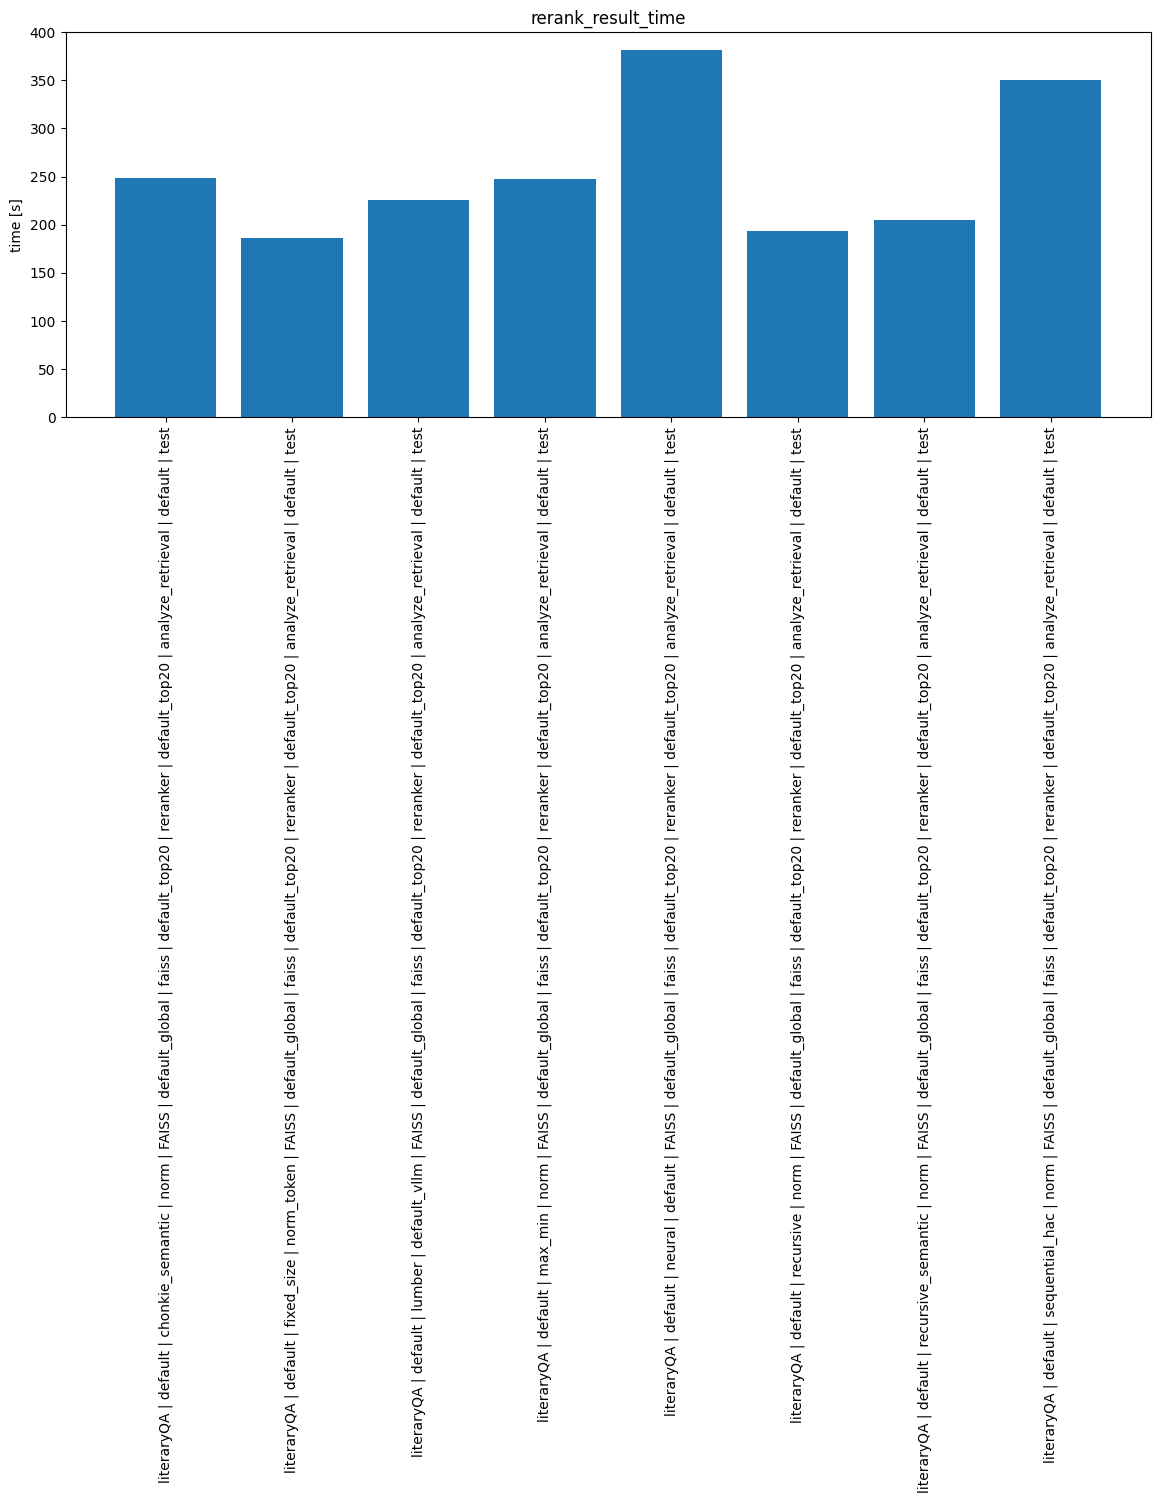

In [10]:
fig, ax = plot_time(retrieval_df, 'rerank_result_time')
plt.show()